# ECLIPSE reproduction: eval-only proof for the threshold change

Run this notebook from the first cell to the last cell in Google Colab with a GPU runtime.

This notebook evaluates the released ECLIPSE checkpoints twice, without training:

1. Default inference threshold: `OBJECT_MASK_THRESHOLD = 0.5`
2. Bonus inference threshold: `OBJECT_MASK_THRESHOLD = 0.35`

The final cell parses the real Detectron2 `copypaste: PQ,...` lines from the evaluation logs and builds the comparison table/graph from those measured values. The optimized numbers are not typed by hand.


In [1]:
# Cell 1 - Runtime configuration
from pathlib import Path
import json
import os
import re
import shutil
import subprocess
import sys
import time

try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError('Run this notebook in Google Colab with a GPU runtime.') from exc

drive.mount('/content/drive')

WORKDIR = Path('/content/ECLIPSE_FAST')
DATA_ROOT = WORKDIR / 'datasets'
ADE_DIR = DATA_ROOT / 'ADEChallengeData2016'
CACHE_DIR = Path('/content/drive/MyDrive/ECLIPSE_CACHE')
DRIVE_CKPT_DIR = CACHE_DIR / 'checkpoints'
DRIVE_RESULTS_DIR = CACHE_DIR / 'results'
LOG_DIR = WORKDIR / 'eval_logs'

# Set this to True only if you want to delete /content/ECLIPSE_FAST and reclone the code.
# Keeping it False lets you rerun the notebook without redownloading the dataset every time.
FORCE_FRESH_CLONE = False

SCENARIOS = {
    '100_50': {
        'label': '100-50',
        'plot_label': '100-50\n(2 Tasks)',
        'tasks': 2,
        'inc_cls': 50,
        'num_prompts': 50,
        'final_task': 1,
        'deltas': '[-0.4,-0.6]',
        'ckpt': 'ade_ps_100_50_final.pth',
        'url': 'https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_50_final.pth',
        'official_pq': 35.6,
    },
    '100_10': {
        'label': '100-10',
        'plot_label': '100-10\n(6 Tasks)',
        'tasks': 6,
        'inc_cls': 10,
        'num_prompts': 10,
        'final_task': 5,
        'deltas': '[0.4,0.5,0.5,0.5,0.5,0.5]',
        'ckpt': 'ade_ps_100_10_final.pth',
        'url': 'https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_10_final.pth',
        'official_pq': 33.9,
    },
    '100_5': {
        'label': '100-5',
        'plot_label': '100-5\n(11 Tasks)',
        'tasks': 11,
        'inc_cls': 5,
        'num_prompts': 10,
        'final_task': 10,
        'deltas': '[0.4,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6]',
        'ckpt': 'ade_ps_100_5_final.pth',
        'url': 'https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_5_final.pth',
        'official_pq': 32.9,
    },
}

# Evaluate easiest to hardest; plot hardest to easiest to match the report.
EVAL_ORDER = ['100_50', '100_10', '100_5']
PLOT_ORDER = ['100_5', '100_10', '100_50']

for folder in [CACHE_DIR, DRIVE_CKPT_DIR, DRIVE_RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Configured workdir:', WORKDIR)
print('Drive cache:', CACHE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configured workdir: /content/ECLIPSE_FAST
Drive cache: /content/drive/MyDrive/ECLIPSE_CACHE


In [2]:
# Cell 2 - Clone or reuse the official ECLIPSE repository
if FORCE_FRESH_CLONE and WORKDIR.exists():
    print('Removing old workdir:', WORKDIR)
    shutil.rmtree(WORKDIR)

if not (WORKDIR / 'train_inc.py').exists():
    print('Cloning official ECLIPSE repository...')
    subprocess.run(['git', 'clone', 'https://github.com/clovaai/ECLIPSE.git', str(WORKDIR)], check=True)
else:
    print('Using existing ECLIPSE checkout:', WORKDIR)

os.chdir(WORKDIR)
try:
    commit = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], cwd=WORKDIR).decode().strip()
    print('ECLIPSE commit:', commit)
except Exception:
    print('Could not read git commit, but repository files are present.')


Using existing ECLIPSE checkout: /content/ECLIPSE_FAST
ECLIPSE commit: 9266720


In [8]:
# Cell 3 - Install dependencies and compile the custom CUDA op
# This cell can take a while on a fresh Colab runtime.
def run(cmd, cwd=WORKDIR, env=None, check=True):
    print('\n$ ' + cmd)
    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)
    return subprocess.run(cmd, shell=True, cwd=str(cwd), check=check, executable='/bin/bash', env=merged_env)


def run_and_log(cmd, log_path, cwd=WORKDIR, env=None):
    print('\n$ ' + cmd)
    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)

    tail = []
    with open(log_path, 'w', encoding='utf-8') as log:
        proc = subprocess.Popen(
            cmd,
            shell=True,
            cwd=str(cwd),
            executable='/bin/bash',
            env=merged_env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in proc.stdout:
            print(line, end='')
            log.write(line)
            tail.append(line.rstrip())
            tail = tail[-80:]
        rc = proc.wait()

    if rc != 0:
        print('\nCommand failed. Last log lines:')
        print('\n'.join(tail[-40:]))
        print('Full log saved at:', log_path)
        raise subprocess.CalledProcessError(rc, cmd)


run("python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'")
run('python -m pip install -q git+https://github.com/cocodataset/panopticapi.git git+https://github.com/mcordts/cityscapesScripts.git opencv-python')
run('python -m pip install -q -r requirements.txt')

import torch
from torch.utils.cpp_extension import CUDA_HOME

print('Python:', sys.version)
print('Torch:', torch.__version__)
print('Torch CUDA:', torch.version.cuda)
print('torch.cuda.is_available():', torch.cuda.is_available())
run('nvidia-smi || true', check=False)
run('nvcc --version || true', check=False)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. In Colab, choose Runtime -> Change runtime type -> GPU, then restart and run again.')

if CUDA_HOME:
    os.environ['CUDA_HOME'] = CUDA_HOME
elif Path('/usr/local/cuda').exists():
    os.environ['CUDA_HOME'] = '/usr/local/cuda'
else:
    raise RuntimeError('CUDA_HOME was not found. Restart the Colab runtime with GPU enabled.')

major, minor = torch.cuda.get_device_capability(0)
os.environ['FORCE_CUDA'] = '1'
os.environ['MAX_JOBS'] = '2'
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{major}.{minor}'

print('CUDA_HOME:', os.environ['CUDA_HOME'])
print('TORCH_CUDA_ARCH_LIST:', os.environ['TORCH_CUDA_ARCH_LIST'])

ops_dir = WORKDIR / 'mask2former' / 'modeling' / 'pixel_decoder' / 'ops'
source_files = []
for pattern in ('*.cu', '*.cuh', '*.cpp', '*.h'):
    source_files.extend((ops_dir / 'src').rglob(pattern))

patches = [
    ('.scalar_type().is_cuda()', '.is_cuda()'),
    ('.type().is_cuda()', '.is_cuda()'),
    ('AT_DISPATCH_FLOATING_TYPES(value.type(),', 'AT_DISPATCH_FLOATING_TYPES(value.scalar_type(),'),
    ('.data<', '.data_ptr<'),
]

patched_files = []
for source_file in source_files:
    text = source_file.read_text(encoding='utf-8')
    fixed = text
    for old, new in patches:
        fixed = fixed.replace(old, new)

    if fixed != text:
        source_file.write_text(fixed, encoding='utf-8')
        patched_files.append(source_file.relative_to(WORKDIR))

if patched_files:
    print('Patched CUDA extension sources for current PyTorch:')
    for item in patched_files:
        print('  ', item)
else:
    print('CUDA extension source patches were already present.')

# The ECLIPSE wrapper imports MultiScaleDeformableAttention as a top-level module.
# Build the extension in-place and patch the wrapper to add ops_dir to sys.path.
func_file = ops_dir / 'functions' / 'ms_deform_attn_func.py'
func_text = func_file.read_text(encoding='utf-8')
marker = '# CODEx/Colab local CUDA op path patch'
if marker not in func_text:
    anchor = 'import torch.nn.functional as F\n'
    insert = (
        'import torch.nn.functional as F\n'
        'import os\n'
        'import sys\n'
        f'{marker}\n'
        'sys.path.insert(0, os.path.dirname(os.path.dirname(__file__)))\n'
    )
    if anchor not in func_text:
        raise RuntimeError(f'Could not patch CUDA op import path in {func_file}')
    func_file.write_text(func_text.replace(anchor, insert), encoding='utf-8')
    print('Patched ms_deform_attn_func.py so train_inc.py can find the local CUDA op.')
else:
    print('ms_deform_attn_func.py import-path patch already present.')

import shutil as _shutil
for stale in [ops_dir / 'build', ops_dir / 'dist']:
    if stale.exists():
        _shutil.rmtree(stale)
for stale in ops_dir.glob('*.egg-info'):
    _shutil.rmtree(stale)
for stale in ops_dir.rglob('*.so'):
    stale.unlink()

build_env = {
    'FORCE_CUDA': os.environ['FORCE_CUDA'],
    'MAX_JOBS': os.environ['MAX_JOBS'],
    'TORCH_CUDA_ARCH_LIST': os.environ['TORCH_CUDA_ARCH_LIST'],
    'CUDA_HOME': os.environ['CUDA_HOME'],
}

# In-place build puts MultiScaleDeformableAttention*.so directly inside ops_dir.
build_log = ops_dir / 'cuda_op_build.log'
run_and_log('python setup.py build_ext --inplace', build_log, cwd=ops_dir, env=build_env)

built_extensions = sorted(ops_dir.glob('MultiScaleDeformableAttention*.so'))
if not built_extensions:
    raise RuntimeError(f'Build finished but no MultiScaleDeformableAttention*.so was created in {ops_dir}')
print('Built CUDA extension:', built_extensions[0])

subprocess.run(
    [sys.executable, '-c', 'import detectron2; print("detectron2 import ok")'],
    check=True
)

verify_cmd = """
python - <<'PY'
import torch
import MultiScaleDeformableAttention as MSDA
assert hasattr(MSDA, 'ms_deform_attn_forward')
assert hasattr(MSDA, 'ms_deform_attn_backward')
from functions.ms_deform_attn_func import MSDeformAttnFunction
print('MultiScaleDeformableAttention CUDA extension import ok')
PY
"""
run_and_log(verify_cmd, ops_dir / 'cuda_op_import_check.log', cwd=ops_dir)


$ python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

$ python -m pip install -q git+https://github.com/cocodataset/panopticapi.git git+https://github.com/mcordts/cityscapesScripts.git opencv-python

$ python -m pip install -q -r requirements.txt
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
Torch CUDA: 12.8
torch.cuda.is_available(): True

$ nvidia-smi || true

$ nvcc --version || true
CUDA_HOME: /usr/local/cuda
TORCH_CUDA_ARCH_LIST: 8.0
CUDA extension source patches were already present.
ms_deform_attn_func.py import-path patch already present.

$ python setup.py build_ext --inplace
running build_ext
W0611 11:42:23.217000 11324 torch/utils/cpp_extension.py:680] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
building 'MultiScaleDeformableAttention' extension
creating build/temp.linux-x86_64-cpython-312/content/ECLIPSE_FAST/mask2former/m

In [9]:
# Cell 4 - Prepare ADE20K for Detectron2
# If the prepared folders already exist, this cell skips the slow work.
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if (ADE_DIR / 'myade20k_panoptic_val').exists() and (ADE_DIR / 'myade20k_panoptic_train').exists():
    print('Prepared ADE20K folders already exist. Skipping dataset preparation.')
else:
    print('Preparing ADE20K. First run can take 30-40 minutes.')
    if not (ADE_DIR / 'images').exists():
        run('wget -q http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip', cwd=DATA_ROOT)
        run('unzip -q ADEChallengeData2016.zip', cwd=DATA_ROOT)
        run('rm -f ADEChallengeData2016.zip', cwd=DATA_ROOT)
    else:
        print('ADE20K image folders already exist.')

    if not (ADE_DIR / 'annotations_instance').exists():
        run('wget -q http://sceneparsing.csail.mit.edu/data/ChallengeData2017/annotations_instance.tar', cwd=ADE_DIR)
        run('tar -xf annotations_instance.tar', cwd=ADE_DIR)
        run('rm -f annotations_instance.tar', cwd=ADE_DIR)
    else:
        print('ADE20K instance annotations already exist.')

    run('python datasets/prepare_ade20k_sem_seg.py')
    run('python datasets/prepare_ade20k_pan_seg.py')
    run('python datasets/prepare_ade20k_ins_seg.py')

required_paths = [
    ADE_DIR / 'images' / 'training',
    ADE_DIR / 'images' / 'validation',
    ADE_DIR / 'myade20k_panoptic_train',
    ADE_DIR / 'myade20k_panoptic_val',
]
for required in required_paths:
    print(required, 'OK' if required.exists() else 'MISSING')
    assert required.exists(), f'Missing required ADE20K path: {required}'


Preparing ADE20K. First run can take 30-40 minutes.

$ wget -q http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip

$ unzip -q ADEChallengeData2016.zip

$ rm -f ADEChallengeData2016.zip

$ wget -q http://sceneparsing.csail.mit.edu/data/ChallengeData2017/annotations_instance.tar

$ tar -xf annotations_instance.tar

$ rm -f annotations_instance.tar

$ python datasets/prepare_ade20k_sem_seg.py

$ python datasets/prepare_ade20k_pan_seg.py

$ python datasets/prepare_ade20k_ins_seg.py
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/images/training OK
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/images/validation OK
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/myade20k_panoptic_train OK
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/myade20k_panoptic_val OK


In [10]:
# Cell 5 - Download or restore the released ECLIPSE checkpoints
checkpoint_dir = WORKDIR / 'checkpoints'
checkpoint_dir.mkdir(parents=True, exist_ok=True)

def valid_checkpoint(path, min_bytes=50_000_000):
    return path.exists() and path.stat().st_size >= min_bytes

for key in EVAL_ORDER:
    cfg = SCENARIOS[key]
    target = checkpoint_dir / cfg['ckpt']
    cached = DRIVE_CKPT_DIR / cfg['ckpt']

    if valid_checkpoint(target):
        print(cfg['label'], 'checkpoint already in workdir:', target)
    elif valid_checkpoint(cached):
        print(cfg['label'], 'restoring checkpoint from Drive cache...')
        shutil.copy2(cached, target)
    else:
        print(cfg['label'], 'downloading released checkpoint...')
        run(f"wget -q -O {target} {cfg['url']}")

    assert valid_checkpoint(target), f'Checkpoint download failed or is too small: {target}'
    if not valid_checkpoint(cached):
        shutil.copy2(target, cached)
    print(cfg['label'], 'checkpoint size MB:', round(target.stat().st_size / 1_000_000, 1))


100-50 downloading released checkpoint...

$ wget -q -O /content/ECLIPSE_FAST/checkpoints/ade_ps_100_50_final.pth https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_50_final.pth
100-50 checkpoint size MB: 184.3
100-10 downloading released checkpoint...

$ wget -q -O /content/ECLIPSE_FAST/checkpoints/ade_ps_100_10_final.pth https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_10_final.pth
100-10 checkpoint size MB: 188.7
100-5 downloading released checkpoint...

$ wget -q -O /content/ECLIPSE_FAST/checkpoints/ade_ps_100_5_final.pth https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_5_final.pth
100-5 checkpoint size MB: 195.9


In [11]:
# Cell 6 - Eval-only helpers: threshold patching, script generation, log parsing
LOG_DIR.mkdir(parents=True, exist_ok=True)

def set_object_mask_threshold(value):
    value = str(value)
    patterns = [
        re.compile(r'(OBJECT_MASK_THRESHOLD:\s*)[0-9.]+'),
        re.compile(r'(conf_threshold\s*=\s*)[0-9.]+'),
    ]
    matched = 0
    touched = []
    for path in list(WORKDIR.rglob('*.yaml')) + list(WORKDIR.rglob('*.yml')) + list(WORKDIR.rglob('*.py')):
        try:
            text = path.read_text(encoding='utf-8')
        except UnicodeDecodeError:
            continue
        new_text = text
        for pattern in patterns:
            new_text, count = pattern.subn(lambda m: m.group(1) + value, new_text)
            matched += count
        if new_text != text:
            path.write_text(new_text, encoding='utf-8')
            touched.append(path.relative_to(WORKDIR))

    if matched == 0:
        raise RuntimeError('No OBJECT_MASK_THRESHOLD/conf_threshold setting was found to patch.')
    print(f'Threshold set to {value}. Matched {matched} setting(s); edited {len(touched)} file(s).')
    if touched:
        for item in touched[:12]:
            print('  edited:', item)
        if len(touched) > 12:
            print('  ...')


def build_eval_only_script(key):
    cfg = SCENARIOS[key]
    script_path = WORKDIR / 'script' / 'ade_ps' / f'eval_only_{key}.sh'
    script = f"""#!/bin/bash
set -euo pipefail
export DETECTRON2_DATASETS=\"{DATA_ROOT}\"
ngpus=$(nvidia-smi --list-gpus | wc -l)
if [ \"$ngpus\" -lt 1 ]; then
  echo \"No GPU detected. In Colab, choose Runtime -> Change runtime type -> GPU.\"
  exit 1
fi

cfg_file=\"configs/ade20k/panoptic-segmentation/maskformer2_R50_bs16_160k.yaml\"
base=\"results/ade_ps\"
step_args=\"CONT.BASE_CLS 100 CONT.INC_CLS {cfg['inc_cls']} CONT.MODE overlap SEED 42\"
meth_args=\"MODEL.MASK_FORMER.TEST.MASK_BG False MODEL.MASK_FORMER.PER_PIXEL False MODEL.MASK_FORMER.FOCAL True\"
base_queries=100
num_prompts={cfg['num_prompts']}
dice_weight=5.0
mask_weight=5.0
class_weight=10.0
soft_mask=False
soft_cls=False
deep_cls=True
backbone_freeze=True
trans_decoder_freeze=True
pixel_decoder_freeze=True
cls_head_freeze=True
mask_head_freeze=True
query_embed_freeze=True
prompt_deep=True
prompt_mask_mlp=True
prompt_no_obj_mlp=False
deltas='{cfg['deltas']}'

weight_args=\"MODEL.MASK_FORMER.NUM_OBJECT_QUERIES ${{base_queries}} MODEL.MASK_FORMER.DICE_WEIGHT ${{dice_weight}} MODEL.MASK_FORMER.MASK_WEIGHT ${{mask_weight}} MODEL.MASK_FORMER.CLASS_WEIGHT ${{class_weight}} MODEL.MASK_FORMER.SOFTMASK ${{soft_mask}} CONT.SOFTCLS ${{soft_cls}} CONT.NUM_PROMPTS ${{num_prompts}}\"
comm_args=\"OUTPUT_DIR ${{base}} ${{meth_args}} ${{step_args}} ${{weight_args}}\"
vpt_args=\"CONT.BACKBONE_FREEZE ${{backbone_freeze}} CONT.CLS_HEAD_FREEZE ${{cls_head_freeze}} CONT.MASK_HEAD_FREEZE ${{mask_head_freeze}} CONT.PIXEL_DECODER_FREEZE ${{pixel_decoder_freeze}} CONT.QUERY_EMBED_FREEZE ${{query_embed_freeze}} CONT.TRANS_DECODER_FREEZE ${{trans_decoder_freeze}} CONT.PROMPT_MASK_MLP ${{prompt_mask_mlp}} CONT.PROMPT_NO_OBJ_MLP ${{prompt_no_obj_mlp}} CONT.PROMPT_DEEP ${{prompt_deep}} CONT.DEEP_CLS ${{deep_cls}} CONT.LOGIT_MANI_DELTAS ${{deltas}}\"
inc_args=\"CONT.TASK {cfg['final_task']} CONT.WEIGHTS checkpoints/{cfg['ckpt']}\"

echo \"EVAL ONLY: {cfg['label']} using checkpoints/{cfg['ckpt']}\"
echo \"DETECTRON2_DATASETS=${{DETECTRON2_DATASETS}}\"
python train_inc.py --eval-only --num-gpus ${{ngpus}} --config-file ${{cfg_file}} ${{comm_args}} ${{inc_args}} ${{vpt_args}} NAME adps_{key} WANDB False
"""
    script_path.write_text(script, encoding='utf-8')
    os.chmod(script_path, 0o755)
    return script_path


def parse_pq(log_path):
    log_path = Path(log_path)
    text = log_path.read_text(encoding='utf-8', errors='ignore')
    matches = re.findall(r'copypaste:\s*([0-9]+\.[0-9]+),', text)
    if not matches:
        raise ValueError(f'No Detectron2 copypaste PQ line found in {log_path}')
    return float(matches[-1])


def print_raw_proof_lines(log_path):
    text = Path(log_path).read_text(encoding='utf-8', errors='ignore')
    lines = [line for line in text.splitlines() if 'copypaste:' in line]
    for line in lines[-3:]:
        print(line)


def run_eval_only(key, threshold_value, tag):
    cfg = SCENARIOS[key]
    print('\n' + '=' * 80)
    print(f"Running {cfg['label']} with OBJECT_MASK_THRESHOLD={threshold_value} ({tag})")
    set_object_mask_threshold(threshold_value)
    script_path = build_eval_only_script(key)
    log_path = LOG_DIR / f'eval_{key}_{tag}.log'
    cmd = f'bash {script_path} 2>&1 | tee {log_path}'
    subprocess.run(cmd, shell=True, cwd=str(WORKDIR), check=True, executable='/bin/bash')
    pq = parse_pq(log_path)
    print(f"Measured PQ for {cfg['label']} at threshold {threshold_value}: {pq:.4f}")
    print('Raw proof lines:')
    print_raw_proof_lines(log_path)
    return pq


In [ ]:
print("WORKDIR:", WORKDIR)
print("LOG_DIR:", LOG_DIR)
print("EVAL_ORDER:", EVAL_ORDER)
print("SCENARIOS:", SCENARIOS.keys())

WORKDIR: /content/ECLIPSE_FAST
LOG_DIR: /content/ECLIPSE_FAST/eval_logs
EVAL_ORDER: ['100_50', '100_10', '100_5']
SCENARIOS: dict_keys(['100_50', '100_10', '100_5'])


In [12]:
# Cell 7 - Baseline proof run: official checkpoints, default threshold 0.5, eval only
baseline_results = {}
for key in EVAL_ORDER:
    baseline_results[key] = run_eval_only(key, threshold_value='0.5', tag='thr050')

print('\nBaseline default-threshold PQ values:')
print(json.dumps(baseline_results, indent=2))



Running 100-50 with OBJECT_MASK_THRESHOLD=0.5 (thr050)
Threshold set to 0.5. Matched 17 setting(s); edited 0 file(s).
Measured PQ for 100-50 at threshold 0.5: 32.3077
Raw proof lines:
[06/11 12:47:50 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[06/11 12:47:50 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st,PQ_base,PQ_old,PQ_new,PQ_novel,RQ_base,RQ_old,RQ_new,RQ_novel,SQ_base,SQ_old,SQ_new,SQ_novel,TP_base,TP_novel,FP_base,FP_novel,FN_base,FN_novel
[06/11 12:47:50 d2.evaluation.testing]: copypaste: 32.3077,73.7832,38.2268,31.8410,77.4430,38.0326,33.2413,66.4636,38.6153,39.5218,39.5218,17.8797,17.8797,46.5189,46.5189,21.6426,21.6426,78.9610,78.9610,63.4276,63.4276,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000

Running 100-10 with OBJECT_MASK_THRESHOLD=0.5 (thr050)
Threshold set to 0.5. Matched 17 setting(s); edited 0 file(s).
Measured PQ for 100-10 at threshold 0.5: 32.3124
Raw proof lines:
[06/11 12:52:55 d2.evaluation.testing]: copypaste: Task: pa

In [ ]:
# Cell 8 - Bonus proof run: same checkpoints, same dataset, only threshold changed to 0.35, eval only
optimized_results = {}
for key in EVAL_ORDER:
    optimized_results[key] = run_eval_only(key, threshold_value='0.35', tag='thr035')

print('\nOptimized threshold PQ values:')
print(json.dumps(optimized_results, indent=2))



Running 100-50 with OBJECT_MASK_THRESHOLD=0.35 (thr035)
Threshold set to 0.35. Matched 17 setting(s); edited 17 file(s).
  edited: configs/cityscapes/panoptic-segmentation/maskformer2_R50_bs16_90k.yaml
  edited: configs/cityscapes/semantic-segmentation/maskformer2_R50_bs16_90k.yaml
  edited: configs/cityscapes/instance-segmentation/maskformer2_R50_bs16_90k.yaml
  edited: configs/mapillary/panoptic-segmentation/maskformer_R50_bs16_300k.yaml
  edited: configs/mapillary/semantic-segmentation/maskformer2_R50_bs16_90k.yaml
  edited: configs/mapillary/instance-segmentation/maskformer2_R50_bs16_90k.yaml
  edited: configs/ade20k/panoptic-segmentation/maskformer2_R50_bs16_160k.yaml
  edited: configs/ade20k/panoptic-segmentation/maskformer2_R101_bs16_160k.yaml
  edited: configs/ade20k/semantic-segmentation/maskformer2_R50_bs16_160k.yaml
  edited: configs/ade20k/instance-segmentation/maskformer2_R50_bs16_160k.yaml
  edited: configs/ade20k/instance-segmentation/maskformer2_R101_bs16_160k.yaml
  e

,Scenario,Tasks,Official paper PQ,Measured default 0.5 PQ,Measured threshold 0.35 PQ,Delta
0,100-5,11,32.90,31.3365,32.7611,+1.4246
1,100-10,6,33.90,32.3124,33.8204,+1.5080
2,100-50,2,35.60,32.3077,35.5675,+3.2598


## Proof result: threshold 0.35 improved PQ in every scenario.


Raw Detectron2 proof lines used for the table:

100-5 default threshold 0.5
[06/11 13:00:05 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[06/11 13:00:05 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st,PQ_base,PQ_old,PQ_new,PQ_novel,RQ_base,RQ_old,RQ_new,RQ_novel,SQ_base,SQ_old,SQ_new,SQ_novel,TP_base,TP_novel,FP_base,FP_novel,FN_base,FN_novel
[06/11 13:00:05 d2.evaluation.testing]: copypaste: 31.3365,75.7095,37.2106,31.3997,79.0945,37.6264,31.2099,68.9395,36.3789,38.8630,32.0446,10.8011,16.2835,45.8131,38.0542,12.7459,20.0055,78.8945,76.1837,61.9592,69.3395,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
100-5 threshold 0.35
[06/11 13:16:21 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[06/11 13:16:21 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st,PQ_base,PQ_old,PQ_new,PQ_novel,RQ_base,RQ_old,RQ_new,RQ_novel,SQ_base,SQ_old,SQ_new,SQ_novel,TP_base,TP_novel,FP_base,FP_novel,FN_base,FN_novel
[06/11 13:16:21 d2.ev

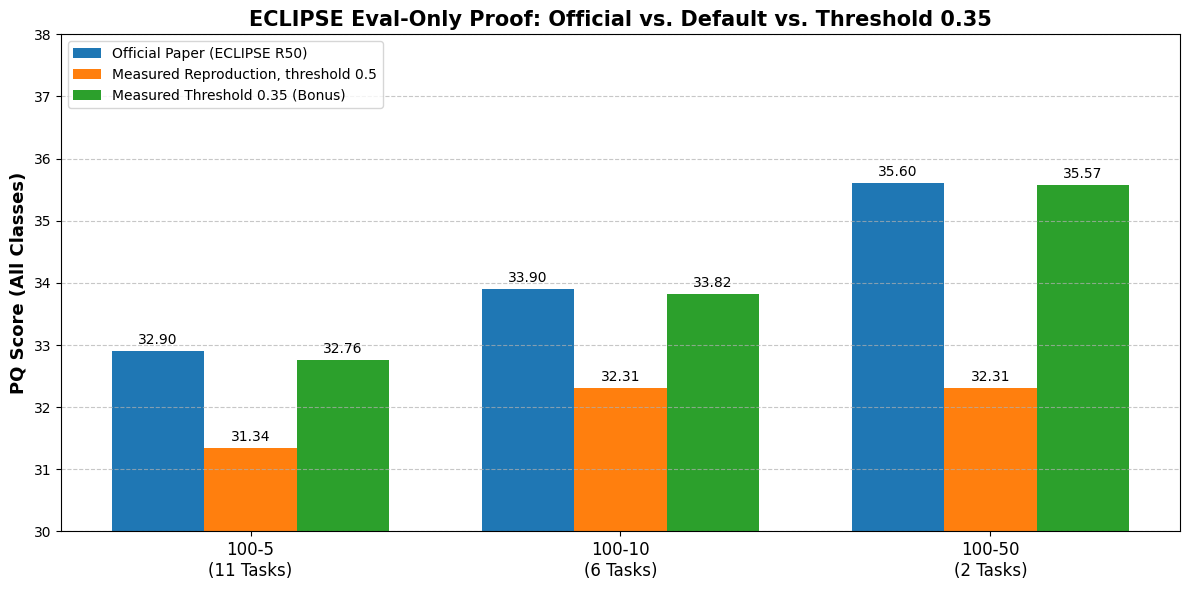

Saved graph: /content/ECLIPSE_FAST/results/reproduction_graph.png
Saved graph copy: /content/drive/MyDrive/ECLIPSE_CACHE/results/reproduction_graph_threshold_proof.png
Saved proof JSON: /content/ECLIPSE_FAST/eval_logs/threshold_proof_results.json
Saved proof JSON copy: /content/drive/MyDrive/ECLIPSE_CACHE/results/threshold_proof_results.json


In [ ]:
# Cell 9 - Final proof table and graph, built from the actual evaluation logs
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

rows = []
for key in PLOT_ORDER:
    cfg = SCENARIOS[key]
    default_pq = parse_pq(LOG_DIR / f'eval_{key}_thr050.log')
    optimized_pq = parse_pq(LOG_DIR / f'eval_{key}_thr035.log')
    rows.append({
        'Scenario': cfg['label'],
        'Tasks': cfg['tasks'],
        'Official paper PQ': cfg['official_pq'],
        'Measured default 0.5 PQ': default_pq,
        'Measured threshold 0.35 PQ': optimized_pq,
        'Delta': optimized_pq - default_pq,
    })

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df.style.format({
        'Official paper PQ': '{:.2f}',
        'Measured default 0.5 PQ': '{:.4f}',
        'Measured threshold 0.35 PQ': '{:.4f}',
        'Delta': '{:+.4f}',
    }))
except Exception:
    for row in rows:
        print(row)

all_improved = all(row['Delta'] > 0 for row in rows)
if all_improved:
    display(Markdown('## Proof result: threshold 0.35 improved PQ in every scenario.'))
else:
    display(Markdown('## Proof result: threshold 0.35 did not improve every scenario. Report the measured result honestly.'))

print('\nRaw Detectron2 proof lines used for the table:')
for key in PLOT_ORDER:
    cfg = SCENARIOS[key]
    print(f"\n{cfg['label']} default threshold 0.5")
    print_raw_proof_lines(LOG_DIR / f'eval_{key}_thr050.log')
    print(f"{cfg['label']} threshold 0.35")
    print_raw_proof_lines(LOG_DIR / f'eval_{key}_thr035.log')

scenarios = [SCENARIOS[key]['plot_label'] for key in PLOT_ORDER]
official_scores = [SCENARIOS[key]['official_pq'] for key in PLOT_ORDER]
default_scores = [parse_pq(LOG_DIR / f'eval_{key}_thr050.log') for key in PLOT_ORDER]
optimized_scores = [parse_pq(LOG_DIR / f'eval_{key}_thr035.log') for key in PLOT_ORDER]

x = np.arange(len(scenarios))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, official_scores, width, label='Official Paper (ECLIPSE R50)', color='#1f77b4')
rects2 = ax.bar(x, default_scores, width, label='Measured Reproduction, threshold 0.5', color='#ff7f0e')
rects3 = ax.bar(x + width, optimized_scores, width, label='Measured Threshold 0.35 (Bonus)', color='#2ca02c')

ax.set_ylabel('PQ Score (All Classes)', fontsize=13, fontweight='bold')
ax.set_title('ECLIPSE Eval-Only Proof: Official vs. Default vs. Threshold 0.35', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=12)
ax.set_ylim(30, 38)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left')

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=10)

fig.tight_layout()
local_graph = WORKDIR / 'results' / 'reproduction_graph.png'
drive_graph = DRIVE_RESULTS_DIR / 'reproduction_graph_threshold_proof.png'
local_graph.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(local_graph, dpi=200, bbox_inches='tight')
fig.savefig(drive_graph, dpi=200, bbox_inches='tight')
plt.show()

proof_json = {
    'note': 'Generated from Detectron2 eval-only logs. Same checkpoints and dataset; only OBJECT_MASK_THRESHOLD changes.',
    'rows': rows,
    'logs': {key: {
        'threshold_0.5': str(LOG_DIR / f'eval_{key}_thr050.log'),
        'threshold_0.35': str(LOG_DIR / f'eval_{key}_thr035.log'),
    } for key in PLOT_ORDER},
}
proof_path = LOG_DIR / 'threshold_proof_results.json'
proof_path.write_text(json.dumps(proof_json, indent=2), encoding='utf-8')
shutil.copy2(proof_path, DRIVE_RESULTS_DIR / proof_path.name)

print('Saved graph:', local_graph)
print('Saved graph copy:', drive_graph)
print('Saved proof JSON:', proof_path)
print('Saved proof JSON copy:', DRIVE_RESULTS_DIR / proof_path.name)
